In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from scipy.io import savemat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt
from gating_functions import phase_based_gating_updated
from admm.utils_moco import stacked_nufft_operator,golden_angle_2d_readout, golden_angle_coords_3d, pocs, phase_based_gating_peak_to_peak, phase_based_gating, create_gates

In [2]:
data_path = Path('/home/lilianae/data/NaF_MtSinai/')
output_path = parent_folder/Path('data/processed/')
print(f'output path = {output_path}')

if not os.path.exists(output_path):
    os.makedirs(output_path)

data_file = data_path /'anon_meas_MID00118_FID60738_Tho_fl3d_star_vibe_991_nav_tj_2000sp_AllCoils_SOS.dat'

multi_twix = twixtools.read_twix(str(data_file))
mapped = twixtools.map_twix(multi_twix)

# mapped[0] is sens data
data_0 = mapped[0]['image']
data_0.flags['remove_os']=True
echo_num=0                                                  # first echo is spoke data
num_points = int(mapped[0]['hdr']['Config']['NImageLins'])  # number of points on one spoke
kspace_0 = data_0[...,echo_num,0,0,0,:,0,0,:,:,:num_points]
kspace_0 = kspace_0.squeeze()
# print(kspace_0.shape)
kspace_0 = np.transpose(kspace_0,(2,0,1,3))
print(kspace_0.shape)  ## Shape = (15, 58, 2002, 256) -> (channels, partitions, lines, columns)
## 58 excitations of the same spoke -> one dimension will be 100,000 (temporal dimension)

output path = /home/lilianae/projects/data/processed
Software version: VD/VE (!?)

Scan  0


100%|██████████| 15.9G/15.9G [00:12<00:00, 1.37GB/s]


(15, 58, 2002, 256)


TR from data: 0.006 sec
Sampling frequency (Hz): 166.667
full timescale goes to 696.69
coil matrix shape: (15, 116116)


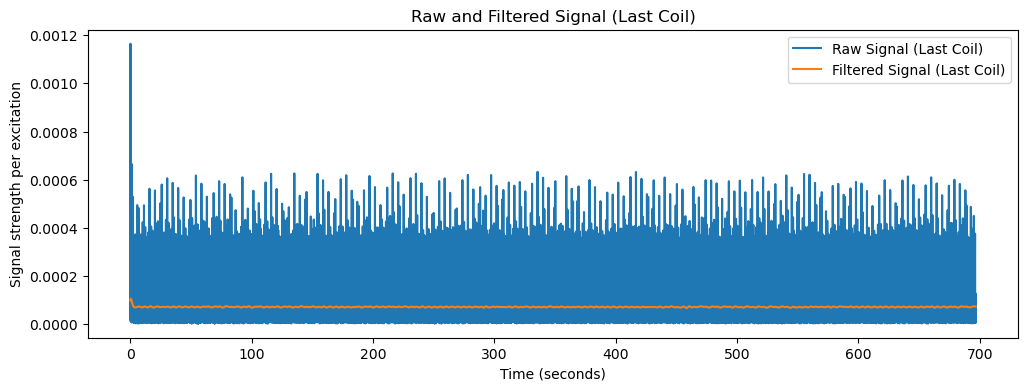

Explained variance ratio: [0.62771117]


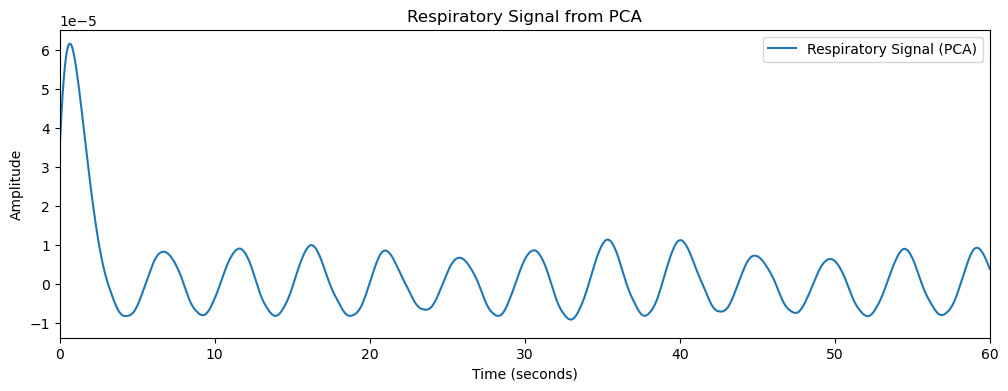

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA

def butter_lowpass_filter(data, cutoff_hz, fs_hz, order=2):
    nyq = 0.5 * fs_hz
    normal_cutoff = cutoff_hz / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def get_resp_signal(ksp_data, mapped):
    num_coils, num_slices, num_spokes, num_samples = ksp_data.shape

    TR = float(mapped[0]['hdr']['Config']['TR'])/1000000. ## microseconds to seconds
    print(f"TR from data: {TR} sec")

    n_samples = num_spokes * num_slices  # total time points/temporal samples

    # Sampling frequency in Hz
    fs = 1/(TR)
    print(f"Sampling frequency (Hz): {fs:.3f}")

    cutoff = 0.25  # respiratory frequency in Hz (~15 bpm)

    # Sanity check: cutoff must be less than Nyquist
    if cutoff >= fs / 2:
        cutoff = 0.49 * fs
        print(f"Cutoff frequency adjusted to: {cutoff:.3f} Hz to stay below Nyquist")

    # Build full time scale in SECONDS
    full_time_scale_s = np.arange(n_samples) * TR  # time in s
    print(f'full timescale goes to {full_time_scale_s[-1]}')

    signal_all_coils = []
    for c in range(num_coils):
        # mean magnitude over samples 130:140, shape (num_slices, num_spokes)
        signal = np.mean(np.abs(ksp_data[c, :, :, 130:140]), axis=-1)
        signal = signal.T.flatten()  # flatten to 1D (time points)

        filtered_signal = butter_lowpass_filter(signal, cutoff, fs, order=2)
        signal_all_coils.append(filtered_signal)

    coil_matrix = np.stack(signal_all_coils, axis=0)  # shape: (coils, time points)

    print(f"coil matrix shape: {coil_matrix.shape}")

    # plot raw and filtered signal from last coil as example (time in seconds)
    plt.figure(figsize=(12, 4))
    plt.plot(full_time_scale_s, signal, label="Raw Signal (Last Coil)")
    plt.plot(full_time_scale_s, signal_all_coils[-1], label="Filtered Signal (Last Coil)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Signal strength per excitation")
    plt.title("Raw and Filtered Signal (Last Coil)")
    plt.legend()
    # plt.xlim(0, 60)  # show first 60 seconds
    plt.show()

    return coil_matrix, TR

def perform_pca(coil_matrix, n_components=1):
    # coil_matrix shape: (coils, time_points)
    data_for_pca = coil_matrix.T  # shape: (time_points, coils)
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(data_for_pca)

    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    return pcs, pca.explained_variance_ratio_

def plot_resp_signal(pcs, TR):
    n_samples = pcs.shape[0]
    time_ms = np.arange(n_samples) * TR
    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, pcs[:, 0], label="Respiratory Signal (PCA)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("Respiratory Signal from PCA")
    plt.legend()
    plt.xlim(0, 60)
    plt.show()

coil_matrix, TR = get_resp_signal(kspace_0, mapped)
pcs, _ = perform_pca(coil_matrix, n_components=1)
plot_resp_signal(pcs, TR)
resp_signal = pcs[:,0]

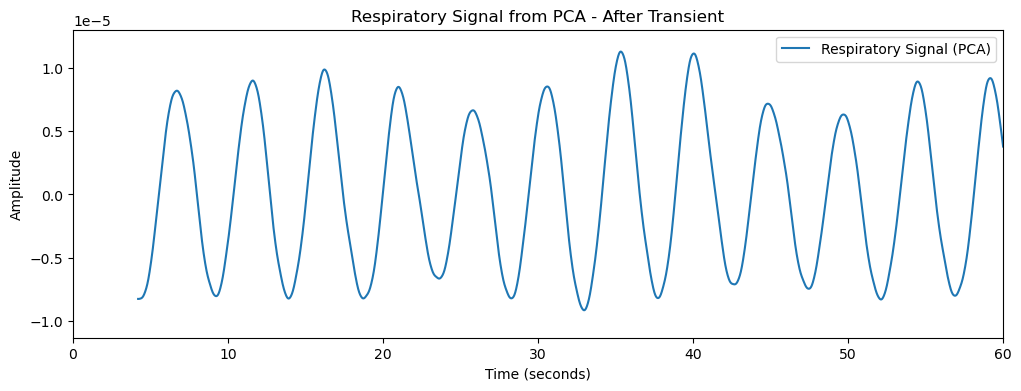

In [8]:
def plot_resp_signal_short(resp, TR):
    n_samples = resp.shape[0]
    time_ms = np.arange(n_samples) * TR
    plt.figure(figsize=(12, 4))
    plt.plot(time_ms[700:], resp[700:], label="Respiratory Signal (PCA)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("Respiratory Signal from PCA - After Transient")
    plt.legend()
    plt.xlim(0, 60)
    plt.show()

plot_resp_signal_short(resp_signal, TR)

### Gating

In [9]:
def create_gates_updated(ksp,coords, idx,num_gates):
    data_bins=[]
    spoke_bins=[]

    for bin in range(1,num_gates+1):
        current_kspace = ksp[:,(idx==bin),:]
        data_bins.append(current_kspace)
        current_ks = coords[(idx==bin),...]
        spoke_bins.append(current_ks)

    return data_bins, spoke_bins

def reshape_gate(data_bin, spoke_bin, num_coils, num_slices, num_samples, ndims):
    N = data_bin.shape[1]
    max_valid = (N // num_slices) * num_slices
    
    data_bin = data_bin[:, :max_valid, :]
    spoke_bin = spoke_bin[:max_valid, :, :]

    num_spokes_per_slice = max_valid // num_slices
    data_bin = data_bin.reshape(num_coils, num_slices, num_spokes_per_slice, num_samples)
    spoke_bin = spoke_bin.reshape(num_slices, num_spokes_per_slice, num_samples, ndims)

    return data_bin, spoke_bin

def gate_resp_signal(ksp_data, resp_signal, num_gates, img_shape, spokes_to_discard=700):
    # Do not use the transient part of the signal (the large overshoot) for gating
    resp_trimmed = resp_signal[spokes_to_discard:]
    
    num_coils, num_slices, num_spokes, num_samples = kspace_0.shape
    idx = phase_based_gating_updated(resp_trimmed, num_gates, order=25)

    ## divide kspace and spoke data:
    img_shape = (58,256,256) 
    coords = golden_angle_coords_3d(img_shape,num_spokes,num_samples)
    ndims = coords.shape[-1]

    ### Combine slice and spoke dimension so we have all temporal samples
    kspace_temporal = np.reshape(kspace_0, (num_coils, num_slices*num_spokes, num_samples))
    kspace_trimmed = kspace_temporal[:, spokes_to_discard:, :]
    coords_temporal = np.reshape(coords, (num_slices*num_spokes, num_samples, ndims))
    coords_trimmed = coords_temporal[spokes_to_discard:, :, :]

    ### Check shape
    # print(f'kspace_trimmed.shape = {kspace_trimmed.shape}')
    # print(f'coords_trimmed.shape = {coords_trimmed.shape}')

    data_bins, spoke_bins = create_gates_updated(kspace_trimmed, coords_trimmed, idx, num_gates)
    for i in range(num_gates):
        data_bins[i], spoke_bins[i] = reshape_gate(data_bins[i], spoke_bins[i], num_coils, num_slices, num_samples, ndims)
        print(f"Gate {i}: kspace shape = {data_bins[i].shape}, coords shape = {spoke_bins[i].shape}")

    return idx, resp_trimmed, data_bins, spoke_bins


ncoils, nslices, nspokes, nsamples = kspace_0.shape
img_shape = (nslices, nsamples, nsamples)
idx, resp_trimmed, data_bins, spoke_bins = gate_resp_signal(kspace_0, resp_signal, num_gates=5, img_shape=img_shape)


Gate 0: kspace shape = (15, 58, 248, 256), coords shape = (58, 248, 256, 3)
Gate 1: kspace shape = (15, 58, 498, 256), coords shape = (58, 498, 256, 3)
Gate 2: kspace shape = (15, 58, 496, 256), coords shape = (58, 496, 256, 3)
Gate 3: kspace shape = (15, 58, 498, 256), coords shape = (58, 498, 256, 3)
Gate 4: kspace shape = (15, 58, 248, 256), coords shape = (58, 248, 256, 3)


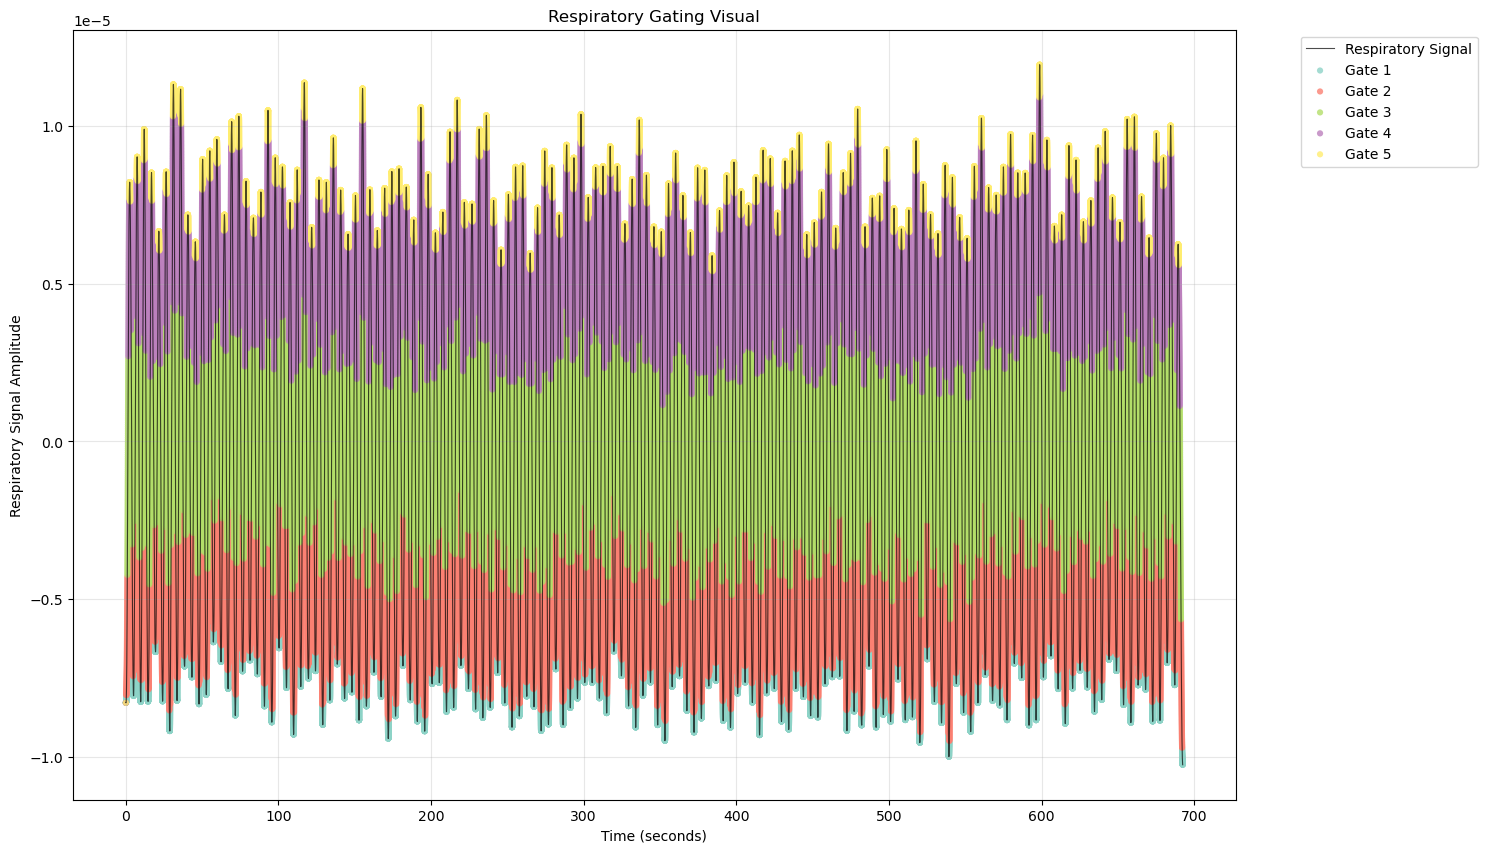

In [10]:
def visualize_resp_gating(resp_signal, idx, TR, num_gates, title="Respiratory Gating Visual"):
    ## 1. Create time axis
    time_s = np.arange(len(resp_signal))*TR

    fig = plt.figure(figsize=(15, 10))

    ## Define colors for gates
    gate_colors = plt.cm.Set3(np.linspace(0,1, num_gates))

    ## Plot 1: Signal with color coded gates
    plt.plot(time_s, resp_signal, 'k-', linewidth=0.8, alpha=0.7, label="Respiratory Signal")

    for i in range(1,(num_gates+1)):
        mask = (idx==i)
        if np.any(mask):
            plt.scatter(time_s[mask], resp_signal[mask],
                        c=[gate_colors[i-1]], s=20, alpha=0.8, label=f'Gate {i}', edgecolors='none')
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Respiratory Signal Amplitude')
    plt.title(f'{title}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_resp_gating(resp_trimmed, idx, TR, num_gates=5)

### Save respiratory arrays

In [12]:
import numpy as np
def save_list_of_arrays(arr_list, filename_prefix, output_dir):
    """
    Save a list of numpy arrays as .npy

    Parameters
    ----------
    arr_list : list of np.ndarray
        List of arrays to save.
    filename_prefix : str
        Prefix for filenames.
    output_dir : Path or str
        Directory to save files.
    """
    for i, arr in enumerate(arr_list):
        fname = output_dir / f"{filename_prefix}_gate{i}.npy"
        np.save(fname, arr)

        ### Also save as .mat
        savemat(f'{filename_prefix}_gate{i}.mat', {f'{filename_prefix}_gate{i}': arr})
        
        print(f"Saved: {fname}")


save_list_of_arrays(spoke_bins, "spoke_bins", output_path)
save_list_of_arrays(data_bins, "data_bins", output_path)

with open(output_path / 'data_bins.pkl', 'wb') as f:
    pickle.dump(data_bins, f)

with open(output_path / 'spoke_bins.pkl', 'wb') as f:
    pickle.dump(spoke_bins, f)

Saved: /home/lilianae/projects/data/processed/spoke_bins_gate0.npy
Saved: /home/lilianae/projects/data/processed/spoke_bins_gate1.npy
Saved: /home/lilianae/projects/data/processed/spoke_bins_gate2.npy
Saved: /home/lilianae/projects/data/processed/spoke_bins_gate3.npy
Saved: /home/lilianae/projects/data/processed/spoke_bins_gate4.npy
Saved: /home/lilianae/projects/data/processed/data_bins_gate0.npy
Saved: /home/lilianae/projects/data/processed/data_bins_gate1.npy
Saved: /home/lilianae/projects/data/processed/data_bins_gate2.npy
Saved: /home/lilianae/projects/data/processed/data_bins_gate3.npy
Saved: /home/lilianae/projects/data/processed/data_bins_gate4.npy
